In [ ]:
from tensorflow.keras.datasets.boston_housing import load_data

In [ ]:
(x_train, y_train), (x_test, y_test) = load_data(path='boston_housing.npz', test_split=0.2, seed=777)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(404, 13) (404,)
(102, 13) (102,)


In [ ]:
import numpy as np

# 데이터 표준화
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# 데이터 분리
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.33, random_state=777)

In [ ]:
print(f'train : {x_train.shape}, {y_train.shape}')
print(f'val : {x_val.shape}, {y_val.shape}')
print(f'test : {x_test.shape}, {y_test.shape}')

train : (270, 13), (270,)
val : (134, 13), (134,)
test : (102, 13), (102,)


In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(13,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer = 'adam',
              loss = 'mse',
              metrics = ['mae'])

In [ ]:
history = model.fit(x_train, y_train, epochs =300,
                    validation_data = (x_val, y_val))

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 559.3710 - mae: 22.0105 - val_loss: 589.7135 - val_mae: 22.1015
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 532.6586 - mae: 21.5056 - val_loss: 553.1673 - val_mae: 21.3337
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 457.8675 - mae: 19.9024 - val_loss: 514.8616 - val_mae: 20.4907
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 413.5447 - mae: 18.8241 - val_loss: 472.0063 - val_mae: 19.5076
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 424.2245 - mae: 18.7038 - val_loss: 422.1790 - val_mae: 18.3004
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 370.1398 - mae: 17.4335 - val_loss: 366.1708 - val_mae: 16.8342
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 307.2261 - mae: 15.8367 - val_loss: 305.3226 - val_mae: 15.0583
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 262.8162 - mae: 14.4623 - val_loss: 244.5036 - val_mae: 13.0058
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━

[10.498299598693848, 2.337761402130127]

In [ ]:
model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.0358 - mae: 2.4419 


[10.498299598693848, 2.337761402130127]

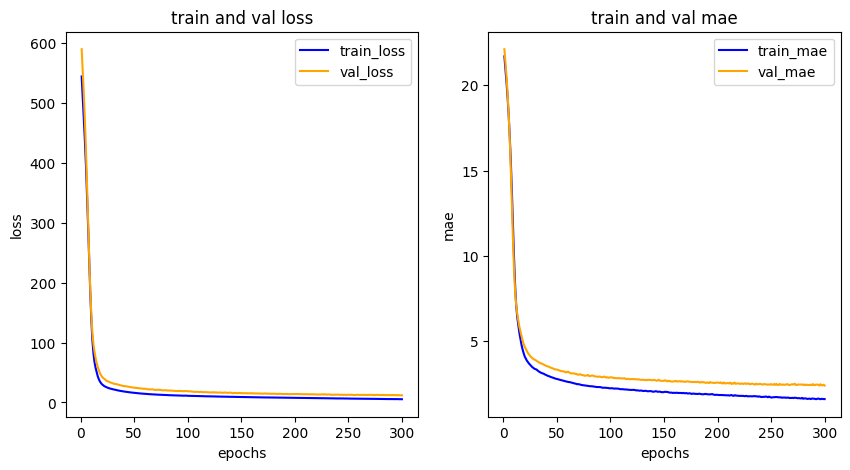

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10,5))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['mae']
val_acc = his_dict['val_mae']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_mae')
ax2.plot(epochs, val_acc, color = 'orange', label='val_mae')
ax2.set_title('train and val mae')
ax2.set_xlabel('epochs')
ax2.set_ylabel('mae')
ax2.legend()

plt.show()

In [ ]:
results = model.predict(x_test).reshape(102,)
print(results.shape)
print(f'results[0]: {results[0]}')
print(f'y_test[0]: {y_test[0]}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(102,)
results[0]: 21.259132385253906
y_test[0]: 21.4


In [ ]:
from tensorflow.keras.datasets.boston_housing import load_data
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import numpy as np

(x_train, y_train), (x_test, y_test) = load_data(path='boston_housing.npz', test_split=0.2, seed=777)

# 데이터 표준화
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [ ]:
from sklearn.model_selection import KFold

k = 3
kfold = KFold(n_splits= k, shuffle = True, random_state = 777)


def get_model():
  model = Sequential()
  model.add(Dense(64, input_shape=(13,), activation='relu'))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1))
  model.compile(optimizer = 'adam',
              loss = 'mse',
              metrics = ['mae'])

  return model

mae_list = []

for train_index, val_index in kfold.split(x_train):
  x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

  model = get_model()

  model.fit(x_train_fold, y_train_fold, epochs=300,
            validation_data = (x_val_fold, y_val_fold))

  _, test_mae = model.evaluate(x_test, y_test)
  mae_list.append(test_mae)

Epoch 1/300


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 548.0977 - mae: 21.7185 - val_loss: 588.8376 - val_mae: 22.0576
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 520.0321 - mae: 21.1017 - val_loss: 553.8655 - val_mae: 21.2971
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 499.1761 - mae: 20.6264 - val_loss: 516.1417 - val_mae: 20.4468
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 415.5642 - mae: 18.8575 - val_loss: 474.3014 - val_mae: 19.4595
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 413.5279 - mae: 18.6153 - val_loss: 424.9338 - val_mae: 18.2431
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 351.8153 - mae: 17.0540 - val_loss: 369.3503 - val_mae: 16.7678
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 311.8307 - mae: 15.7111 - val_loss: 308.2435 - val_mae: 15.0032
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 248.6688 - mae: 14.0008 - val_loss: 244.2225 - val_mae: 12.9649
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
print(mae_list)

[2.1408798694610596, 2.0843281745910645, 2.3261752128601074]


In [ ]:
print(np.mean(mae_list))

2.1837944189707437
